In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
# define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# data into training and val

BATCH_SIZE = 128 # 128 images will be feed in batches.

data_transform = transforms.Compose([transforms.ToTensor()]) # img to tensor, scale pixel between 0 and 1.

train_dataset = datasets.MNIST(root = "./data", train = True, transform = data_transform, download = True) # loads data

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.55MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.3MB/s]


In [40]:
# class that defines autoencoder
class AutoEncoder(nn.Module):
  def __init__(self, latent_dim = 3, hidden_dim = 256):
    super().__init__()

    # Encoder
    self.encoder = nn.Sequential(
        nn.Linear(784, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, latent_dim),
        # nn.ReLU()
    )


    # Decoder
    self.decoder = nn.Sequential(nn.Linear(latent_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 784),
        nn.Sigmoid())

  def forward(self, x):
    z = self.encoder(x)
    x_recon = self.decoder(z)
    return x_recon

In [41]:
model = AutoEncoder()

criterion = nn.MSELoss() # setting up loss function
optimizer = optim.Adam(model.parameters(), lr = 1e-3) # setting up optimizer and learning rate = 0.001

In [42]:
epochs = 20

model.train()
for epoch in range(epochs):
  total_loss = 0
  for x, _ in train_loader: # taking batches one by one
    x = x.view(-1, 784).to(device)

    optimizer.zero_grad()
    x_recon = model(x)
    loss = criterion(x_recon, x)
    loss.backward()
    optimizer.step()

    total_loss = total_loss + loss.item()

  avg_loss = total_loss / len(train_loader)
  print(f'Epoch [{epoch + 1} / {epochs}], Loss : {avg_loss:.6f}')



Epoch [1 / 20], Loss : 0.054544
Epoch [2 / 20], Loss : 0.042936
Epoch [3 / 20], Loss : 0.040691
Epoch [4 / 20], Loss : 0.039462
Epoch [5 / 20], Loss : 0.038655
Epoch [6 / 20], Loss : 0.038034
Epoch [7 / 20], Loss : 0.037553
Epoch [8 / 20], Loss : 0.037127
Epoch [9 / 20], Loss : 0.036781
Epoch [10 / 20], Loss : 0.036470
Epoch [11 / 20], Loss : 0.036197
Epoch [12 / 20], Loss : 0.035951
Epoch [13 / 20], Loss : 0.035739
Epoch [14 / 20], Loss : 0.035539
Epoch [15 / 20], Loss : 0.035363
Epoch [16 / 20], Loss : 0.035203
Epoch [17 / 20], Loss : 0.035064
Epoch [18 / 20], Loss : 0.034917
Epoch [19 / 20], Loss : 0.034786
Epoch [20 / 20], Loss : 0.034664


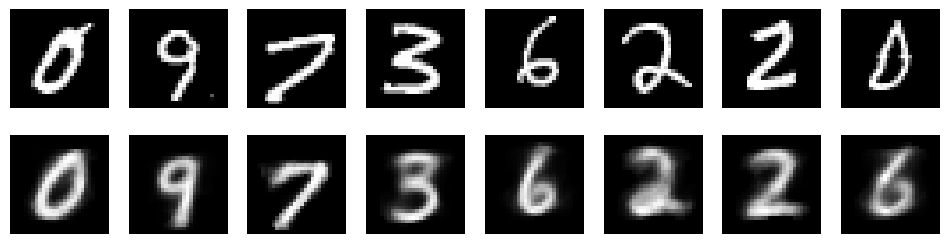

In [43]:
n = 8
plt.figure(figsize = (12,3))

for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(x[i].detach().cpu().view(28,28), cmap = 'gray')
  plt.axis('off')

  plt.subplot(2,n,i+1+n)
  plt.imshow(x_recon[i].detach().cpu().view(28,28), cmap = 'gray')
  plt.axis('off')

plt.show()

In [44]:
model.eval()

latents = []
labels = []

with torch.no_grad():
    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        z = model.encoder(x)

        latents.append(z.cpu())
        labels.append(y)

latents = torch.cat(latents, dim=0)
labels = torch.cat(labels, dim=0)

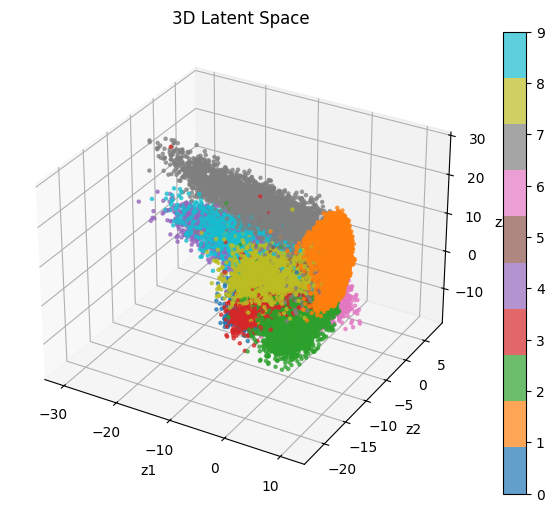

In [45]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

latent_dim = latents.shape[1]

# Ensure numpy
Z = latents.detach().cpu().numpy()
y = labels.detach().cpu().numpy()

if latent_dim == 1:
    # ---- 1D: Histogram + Strip plot ----
    plt.figure(figsize=(8, 4))
    for digit in range(10):
        plt.hist(
            Z[y == digit].flatten(),
            bins=50,
            alpha=0.5,
            label=str(digit)
        )
    plt.xlabel("Latent value")
    plt.ylabel("Frequency")
    plt.title("1D Latent Distribution by Class")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 3))
    plt.scatter(Z.flatten(), y, s=5, alpha=0.5)
    plt.xlabel("Latent value")
    plt.ylabel("Digit class")
    plt.title("1D Latent Strip Plot")
    plt.show()

elif latent_dim == 2:
    # ---- 2D Scatter ----
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        Z[:, 0], Z[:, 1],
        c=y, cmap="tab10",
        s=5, alpha=0.7
    )
    plt.colorbar(scatter, ticks=range(10))
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.title("2D Latent Space")
    plt.show()

elif latent_dim == 3:
    # ---- 3D Rotatable Scatter ----
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    scatter = ax.scatter(
        Z[:, 0], Z[:, 1], Z[:, 2],
        c=y, cmap="tab10",
        s=5, alpha=0.7
    )
    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
    ax.set_zlabel("z3")
    ax.set_title("3D Latent Space")
    fig.colorbar(scatter, ticks=range(10))
    plt.show()

else:
    # ---- >3D: PCA Projection ----
    # pca_dim = 3 if latent_dim >= 3 else 2
    pca_dim = 2
    pca = PCA(n_components=pca_dim)
    Z_pca = pca.fit_transform(Z)

    if pca_dim == 2:
        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(
            Z_pca[:, 0], Z_pca[:, 1],
            c=y, cmap="tab10",
            s=5, alpha=0.7
        )
        plt.colorbar(scatter, ticks=range(10))
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title("PCA Projection of Latent Space (>3D)")
        plt.show()

    else:
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection="3d")
        scatter = ax.scatter(
            Z_pca[:, 0], Z_pca[:, 1], Z_pca[:, 2],
            c=y, cmap="tab10",
            s=5, alpha=0.7
        )
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_zlabel("PC3")
        ax.set_title("3D PCA Projection of Latent Space (>3D)")
        fig.colorbar(scatter, ticks=range(10))
        plt.show()
